## Need this here

In [662]:
import numpy as np

In [663]:
from typing import List, NamedTuple
Edge = NamedTuple('Edge', [('v', int), ('w', int)]) # edge contains two indices to coordinates-array

In [664]:
def compute_partitions(coordinates: np.ndarray, partitions: int) -> List[np.ndarray]:
    """
    Partitions the coordinates into an array of indices. For this matter we use the angles
    between the reference vector of the x-axis.

    :param coordinates: a 2D real array of x- and y-coordinates
    :param partitions: number of partitions
    :return: list of arrays that contain indices of heliostats with regards to the coordinates array
    """
    if partitions > len(coordinates) - 1: # not enough heliostats
        return []

    degrees = np.degrees(np.arctan2(coordinates[1:,1], coordinates[1:,0]))
    indices = degrees.argsort()
    padding = (-len(indices))%partitions
    L = np.split(np.concatenate((indices,np.ones(padding)*-1)),partitions) # padding value: -1
    # remove padding from last partition and increase index
    return [np.delete(a, np.where(a == -1)) + 1 for a in L]


In [811]:
class EdgeSolution:
    def __init__(self, partitions: int) -> None:
        """
        :param partitions: number of edge partitions
        """
        self.edges= [[] for _ in range(partitions)] # type: List[List[Edge]]
        self.edges_coords = [np.empty((0,4)) for _ in range(partitions)]
        self.edge_costs = {} # type: Dict[Edge,int]

    def add_edge(self, edge: Edge, edge_cost: float, partition: int, coordinates: np.ndarray):
        self.edges[partition].append(edge)
        self.edge_costs[edge] = edge_cost

        edges_coords = np.array([[coordinates[edge.v][0], coordinates[edge.v][1],
                                 coordinates[edge.w][0], coordinates[edge.w][1]]])
        self.edges_coords[partition] = np.vstack((self.edges_coords[partition], edges_coords))

    def remove_edge(self, edge: Edge, partition: int, coordinates: np.ndarray):
        self.edges[partition].remove(edge)
        del self.edge_costs[edge]

        edges_coords = np.array([[coordinates[edge.v][0], coordinates[edge.v][1],
                                 coordinates[edge.w][0], coordinates[edge.w][1]]])
        delete_index = np.where(np.all(edges_coords == self.edges_coords[partition], axis=1))
        self.edges_coords[partition] = np.delete(self.edges_coords[partition], delete_index, axis=0)

    def intersects(self, edges_coords: np.ndarray) -> bool:
        """
        Checks whether a given edge that is represented by its coordinates is intersecting
        with our solution edges.

        :param edges_coords: a numpy array that holds both x- and y-coordinates
        :returns: True if edges_coords intersects with solution edges
        """
        return is_edge_intersecting(edges_coords, self.edges_coords)

    def cost(self, distances: np.ndarray):
        return sum(distances[e.v,e.w]*self.edge_costs[e] for e in chain.from_iterable(self.edges))

In [803]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def plot_solution_data(coordinates: np.ndarray,
                       output: str,
                       edges: List[List[Edge]],
                       value: float,
                       edge_cost: float,
                       partitions: int) -> None:
    plt.figure(figsize=(16,16), dpi=350)
    plt.axis('equal')

    coordinates_arr = np.array([tuple(x) for x in coordinates])
    for i,all_edges in enumerate(edges):
        edges_arr = np.array([tuple(list(x)) for x in all_edges])

        x = coordinates_arr[:,0].flatten()
        y = coordinates_arr[:,1].flatten()

        norm = matplotlib.colors.Normalize(vmin=0, vmax=len(edges), clip=True)
        mapper = cm.ScalarMappable(norm=norm, cmap=cm.cool)

        plt.plot(x[edges_arr.T], y[edges_arr.T], linestyle='-', color=mapper.to_rgba(i),
                 markerfacecolor='red', marker='o')
    plt.title("Cable cost/m: {}€ \nPartitions: {}\nTotal costs: {:0,.2f}€".format(edge_cost, partitions, value))
    plt.scatter(coordinates_arr[:,0], coordinates_arr[:,1], color='red', marker='o')
    plt.savefig(output, dpi=300)
    plt.close()


/home/duc/virtualenvs/all/lib/python3.6/site-packages/ipykernel_launcher.py:2: UserWarning: 
This call to matplotlib.use() has no effect because the backend has already
been chosen; matplotlib.use() must be called *before* pylab, matplotlib.pyplot,
or matplotlib.backends is imported for the first time.

The backend was *originally* set to 'module://ipykernel.pylab.backend_inline' by the following code:
  File "/usr/lib/python3.6/runpy.py", line 193, in _run_module_as_main
    "__main__", mod_spec)
  File "/usr/lib/python3.6/runpy.py", line 85, in _run_code
    exec(code, run_globals)
  File "/home/duc/virtualenvs/all/lib/python3.6/site-packages/ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "/home/duc/virtualenvs/all/lib/python3.6/site-packages/traitlets/config/application.py", line 658, in launch_instance
    app.start()
  File "/home/duc/virtualenvs/all/lib/python3.6/site-packages/ipykernel/kernelapp.py", line 478, in start
    self.io_loop.start()


## NEW SOLUTION CLASS

In [860]:
from typing import Generator

class PowerCableSolution(EdgeSolution):
    def __init__(self, n: int, partitions: int, highest_cable_cost: float, highest_cable_length: float, highest_cable_apacity: float):
        """
        :param n: number of vertices
        :param partitions: number of partitions
        """
        super().__init__(partitions)
        self.predecessor = np.zeros(n, dtype=int)
        self.predecessor[0] = -1
        
        self.successors = {i:[] for i in range(n)} # type: Dict[int,List[int]]
        self.number_children_heliosats = {i:0 for i in range(n)} # type: Dict[int,int]
        self.parents = {i:[0] for i in range(n)} # type: Dict[int,List[int]]
        
        self.current_cap = np.ones(n)
        self.current_cap[0] = n - 1
        
        self.current_max_cap = np.ones(n) * highest_cable_apacity
        
        # NOTE: needs refactoring
        self.current_cable_cost = np.ones(n) * highest_cable_cost
        self.current_cable_cost[0] = 0
        
        self.current_max_cable_length = np.ones(n) * highest_cable_length

    def add_edge(self, edge: Edge, edge_cost: float, partition: int, coordinates: np.ndarray):
        super().add_edge(edge, edge_cost, partition, coordinates)
        self.predecessor[edge.w] = edge.v
        self.successors[edge.v].append(edge.w)
        
        for parent in self.heliostat_parents[edge.w]:
            self.number_children_heliosats[parent] += 1

    def remove_edge(self, edge: Edge, partition: int, coordinates: np.ndarray):
        super().remove_edge(edge, partition, coordinates)
        self.predecessor[edge.w] = -1
        self.successors[edge.v].remove(edge.w)
        
        for parent in self.heliostat_parents[edge.w]:
            self.number_children_heliosats[parent] -= 1

    def cost(self, distances: np.ndarray):
        return super().cost(distances)
    
    def heliostat_parents(self, vertex: int) -> Generator[int,None,None]:
        """
        Generator that computes the parent vertices up to the
        solar tower.
        
        :param vertex: starting vertex from where we start obtaining predecessor vertices
        """
        pred = vertex
        while pred in self.predecessor:
            yield self.predecessor[pred]
            pred = self.predecessor[pred]

## NEW ALGORITHM CLASS

In [774]:
from typing import List
from recordclass import RecordClass
from scipy.spatial.distance import cdist

MCMSTState = RecordClass('MCMSTState', [('unvisited', List[int])])
Candidate = RecordClass('Candidate', [('vertex', int),
                                      ('edge_cost', float),
                                      ('edges_add', List[Edge]),
                                      ('edges_remove', List[Edge])])

class MCMST:
    # __slots__ = ('coordinates', 'edge_costs', 'partitions', 'solution', 'current_state')
    
    def __init__(self,
                 coordinates: np.ndarray,
                 cable_costs: List[float],
                 partitions: int,
                 work_cost: float,
                 open_trenches: List[List[Edge]],
                 cable_cost: np.ndarray,
                 cable_length: np.ndarray,
                 cable_capacity):
        """
        todoc
        !assume cable_costs is sorted in ascending order!
        """
        self.coordinates = coordinates
        self.cable_costs = cable_costs
        self.partitions = partitions
        self.solution = PowerCableSolution(self.coordinates.shape[0], partitions)
        
        self.distances = cdist(coordinates,coordinates)
        indices = np.vstack(open_trenches)
        self.trench_cost = np.self.distances[indices[:,0], indices[:,1]]*trench_cost
        
        self.cable_cost = cable_cost
        self.cable_length = cable_length
        self.cable_capacity = cable_capacity
        
    def compute(self) -> None:
        for i, p in enumerate(compute_partitions(coordinates=self.coordinates, partitions=self.partitions)):
            self.current_state = MCMSTState(unvisited=p)
            self._mcmst(i, p)
            
    def _mcmst(self, partition, partition_indices) -> None:
        """
        """
        for i,_ in enumerate(reversed(self.cable_costs)):
            for candidate in self.next_candidate(partition_indices, i):
                self._upgrade_vertex(partition, candidate)
                
    def next_candidate(self, partition_indices: np.ndarray, i: int) -> Generator[Candidate,None,None]:
        """
        :param partition_indices:
        :param i: index to self.cable_costs
        """
        for self.current_state.unvisited:
            pass # TODO
            
    
    def _upgrade_vertex(self, partition: int, candidate: Candidate) -> None:
        
        
    def _upgrade_cost(self, vertex: np.ndarray, cable_index: int):
        i = vertex
        pred = self.solution.predecessor[i]
        current_cost = self.distance[pred,i] * self.solution.current_cable_cost
        after_reconnection_cost = self.distance[pred,i] * self.cable_cost[cable_index]
        cost = current_cost - after_reconnection_cost

        # mask away upgrades that 
        if self.distance[pred,i] > cable_length[cable_index]:
            return np.inf
        else:
            return cost
        
    def _reconnecting_profit(self, candidates: np.ndarray, new_parent: int):
        j = candidates
        old_cost = self.distance[self.solution.predecessor[j],j]*self.solution.current_cable_cost[j]
        profit =  old_cost - self.distance[new_parent,j]*self.solution.current_cable_cost[j]
        return profit
    
    def _max_number_reconnections(self, new_parent: int) -> int:
        indices = self.solution.parents[new_parent]
        return np.min(self.solution.current_max_cap[indices] - self.solution.current_cap[indices])
    
    def _candidate_indices(self, new_parent: int, forbidden_candidates):
        """
        :param new_parent: new parent for candidates
        """
        candidates = np.arange(self.coordinates.shape[0])
        candidates = np.setdiff1d(candidates, forbidden_candidates)

        # capacity constraint
        mask_capacity = self.solution.current_cap[candidates] < self._max_number_reconnections(new_parent)
        mask_capacity[0] = False
        mask_capacity[new_parent] = False

        # cable length constraint
        mask_cable_length = self.distance[new_parent,candidates] < self.solution.current_max_cable_length[candidates]

        return self.candidates[np.logical_and(mask_capacity, mask_cable_length)]
    
    def _best_candidates(self, new_parent: int, cable_index: int, forbidden_candidates: np.ndarray):
        candidates = self._candidate_indices(new_parent, forbidden_candidates)
        profit = self._reconnecting_profit(candidates, new_parent) - self._upgrade_cost(new_parent, cable_index)
        i = np.argmax(profit)
        if profit[i] > 0:
            return candidates[i], profit[i]
        else:
            return -1, 0

SyntaxError: invalid syntax (<ipython-input-774-c973345f117f>, line 45)

## PERFORM

In [26]:
coordinates = np.loadtxt('../data/instances/PS10.csv', delimiter=';')
coordinates = np.vstack((np.array([0,0]), coordinates))

In [ ]:
MCMST(coordinates, [])

In [ ]:
q = cdist(coordinates, coordinates)
plot_solution_data(coordinates, '/home/duc/a.png', mcmst.solution.edges, mcmst.solution.cost(q), -1, 3)

## PLAYGROUND

In [669]:
coords = coordinates[:20].copy()

In [670]:
import matplotlib.pyplot as plt

In [671]:
%matplotlib inline

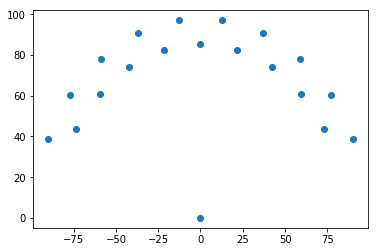

In [672]:
plt.scatter(coords[:,0], coords[:,1])
plt.show()

In [673]:
plt.close()

In [675]:
cable_cost = np.array([0.58,0.87,1.24,1.95,3.13,5.19,6.9])
cable_length = np.array([38.36,47.08,56.04,69.3,84.87,102.79,120.31])
cable_capacity = np.array([56,73,92,124,162,209,250])

In [676]:
from scipy.spatial.distance import cdist

In [858]:
# init stuff

## capacities
current_cap = np.ones(coords.shape[0])
current_cap[0] = coords.shape[0] - 1

current_max_cap = np.ones(coords.shape[0]) * np.max(cable_capacity)

# cable length
current_max_cable_length = np.ones(coords.shape[0]) * np.max(cable_length)

## cost to parent
current_cable_cost = np.ones(coords.shape[0]) * np.max(cable_cost)
#current_cable_cost = np.zeros(coords.shape[0])
current_cable_cost[0] = 0

## 
parents = {i:[0] for i in range(coords.shape[0])}
parents[0] = None

pred = np.zeros(coords.shape[0], dtype=int)
pred[0] = -1

# distances
distance = cdist(coords, coords)

In [678]:
def upgrade_cost(vertex: np.ndarray, cable_index: int):
    i = vertex
    cost = distance[pred[i],i]*current_cable_cost[i] - distance[pred[i],i]*cable_cost[cable_index]
    
    # mask away upgrades that 
    if distance[pred[i],i] > cable_length[cable_index]:
        return np.inf
    else:
        return cost

In [679]:
def reconnecting_profit(candidates: np.ndarray, new_parent: int):
    j = candidates
    profit = distance[pred[j],j]*current_cable_cost[j] - distance[new_parent,j]*current_cable_cost[j]
    return profit

In [680]:
def max_number_reconnections(new_parent: int) -> int:
    indices = parents[new_parent]
    return np.min(current_max_cap[indices] - current_cap[indices])

In [681]:
def candidate_indices(new_parent: int, forbidden_candidates):
    """
    :param new_parent: new parent for candidates
    """
    candidates = np.arange(coords.shape[0])
    candidates = np.setdiff1d(candidates, forbidden_candidates)
    
    # capacity constraint
    mask_capacity = current_cap[candidates] < max_number_reconnections(new_parent)
    mask_capacity[0] = False
    mask_capacity[new_parent] = False
    
    # cable length constraint
    mask_cable_length = distance[new_parent,candidates] < current_max_cable_length[candidates]
    
    return candidates[np.logical_and(mask_capacity, mask_cable_length)]

In [750]:
def best_candidates(new_parent: int, cable_index: int, forbidden_candidates: np.ndarray):
    candidates = candidate_indices(new_parent, forbidden_candidates)
    profit = reconnecting_profit(candidates, new_parent) - upgrade_cost(new_parent, cable_index)
    i = np.argmax(profit)
    if profit[i] > 0:
        return candidates[i], profit[i]
    else:
        return -1, 0

In [849]:
## perform

In [855]:
upgraded = set()

In [854]:
for i in reversed(range(len(cable_cost))):
    while()

6
5
4
3
2
1
0


In [856]:
d = {i:[] for i in range(1,coords.shape[0])}
p = {i:0 for i in range(1,coords.shape[0])}

In [857]:
while(True):
    updated=False
    for k in d:
        candidate, profit = best_candidates(1,3, np.array(d[k]))
        if candidate != -1:
            d[k].append(candidate)
            p[k] += profit
            updated=True
    else:
        if not updated:
            break

TypeError: 'int' object is not subscriptable

In [841]:
# init
solution = PowerCableSolution(coords.shape[0], 1)
for i in range(1,coords.shape[0]):
    solution.add_edge(Edge(0,i),cable_cost[6],0,coords)

In [842]:
solution.edge_costs

{Edge(v=0, w=1): 6.9,
 Edge(v=0, w=2): 6.9,
 Edge(v=0, w=3): 6.9,
 Edge(v=0, w=4): 6.9,
 Edge(v=0, w=5): 6.9,
 Edge(v=0, w=6): 6.9,
 Edge(v=0, w=7): 6.9,
 Edge(v=0, w=8): 6.9,
 Edge(v=0, w=9): 6.9,
 Edge(v=0, w=10): 6.9,
 Edge(v=0, w=11): 6.9,
 Edge(v=0, w=12): 6.9,
 Edge(v=0, w=13): 6.9,
 Edge(v=0, w=14): 6.9,
 Edge(v=0, w=15): 6.9,
 Edge(v=0, w=16): 6.9,
 Edge(v=0, w=17): 6.9,
 Edge(v=0, w=18): 6.9,
 Edge(v=0, w=19): 6.9}

In [845]:
def update(parent: int):
    for candidate in d[parent]:
        pp = solution.predecessor[candidate]
        solution.remove_edge(Edge(pp,candidate), 0, coords)
        solution.add_edge(Edge(1,candidate), cable_cost[6], 0, coords)

    #old_pp = solution.predecessor[parent] # we lose this
    solution.edge_costs[solution.predecessor[parent], parent] = cable_cost[6]
    #solution.remove_edge(Edge(old_pp,parent), 0, coords)
    #solution.add_edge(Edge(old_pp,parent), cable_cost[6], 0, coords)

In [846]:
update(1)

In [835]:
solution.predecessor

{1: 0,
 2: 1,
 3: 1,
 4: 1,
 5: 1,
 6: 0,
 7: 0,
 8: 0,
 9: 0,
 10: 1,
 11: 1,
 12: 1,
 13: 1,
 14: 1,
 15: 0,
 16: 0,
 17: 0,
 18: 0,
 19: 0}

In [836]:
solution.edges

[[Edge(v=0, w=6),
  Edge(v=0, w=7),
  Edge(v=0, w=8),
  Edge(v=0, w=9),
  Edge(v=0, w=15),
  Edge(v=0, w=16),
  Edge(v=0, w=17),
  Edge(v=0, w=18),
  Edge(v=0, w=19),
  Edge(v=1, w=11),
  Edge(v=1, w=10),
  Edge(v=1, w=2),
  Edge(v=1, w=12),
  Edge(v=1, w=3),
  Edge(v=1, w=13),
  Edge(v=1, w=4),
  Edge(v=1, w=14),
  Edge(v=1, w=5),
  Edge(v=0, w=1)]]

In [840]:
plot_solution_data(coords, '/home/duc/a.png', solution.edges, -1, -1, 1)